# 📘 Bài Giảng Thực Hành: Hồi Quy Tuyến Tính Đa Biến (Multiple Linear Regression)
**Mục tiêu bài giảng:**
1. Hiểu và áp dụng phương trình Hồi quy Tuyến tính Đa biến: $y = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n$.
2. Tiền xử lý biến phân loại (Categorical Data) bằng `ColumnTransformer` + `OneHotEncoder(drop='first')` để tránh **Bẫy Biến Giả (Dummy Variable Trap)**.
3. Sử dụng `LinearRegression` từ Scikit-Learn để tìm các hệ số trọng số tối ưu.
4. Xây dựng hàm `compare(i_example)` giải mã ngược nhãn `State` và lập bảng so sánh Actual vs Predicted.
5. Áp dụng thuật toán **Loại Bỏ Ngược (Backward Elimination)** bằng kiểm định p-value qua `statsmodels.api.OLS` để chọn lọc biến có ý nghĩa thống kê.
6. Trực quan hóa giá trị Thực tế vs Dự đoán và mức độ tác động của các biến đặc trưng.

---
### 📊 Tập dữ liệu thực hành: `50_Startups.csv`
- **Features ($X$)**:
  - `State`: Bang trụ sở (New York, California, Florida - Dữ liệu Categorical).
  - `R&D Spend`: Chi phí Nghiên cứu & Phát triển ($).
  - `Administration`: Chi phí Quản trị & Vận hành ($).
  - `Marketing Spend`: Chi phí Tiếp thị & Quảng cáo ($).
- **Target ($y$)**: `Profit` - Lợi nhuận của doanh nghiệp Startup ($).

## 1. Đọc & Khám phá Dữ liệu


In [6]:
import pandas as pd

dataset = pd.read_csv('50_Startups.csv')
print('Số lượng mẫu:', len(dataset))
dataset.head()


Số lượng mẫu: 50


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


📌 **Expected Output:**
```
Số lượng mẫu: 50
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94
```


## 2. Tiền Xử Lý: One-Hot Encoding Biến 'State' (Tránh Dummy Variable Trap) & Chia Train / Test
- Cột `State` là biến phân loại dạng chuỗi (`'New York'`, `'California'`, `'Florida'`), cần được chuyển sang dạng số bằng **One-Hot Encoding**.
- **Nguyên lý Bẫy Biến Giả (Dummy Variable Trap):** Khi biến có $k = 3$ nhóm, ta chỉ giữ lại $k - 1 = 2$ cột biến giả (dùng `drop='first'`). Cột bị loại bỏ (`State_California`) đóng vai trò làm nhóm cơ sở (baseline). Nếu giữ cả 3 cột, tổng của chúng luôn bằng 1, gây ra hiện tượng **Đa cộng tuyến hoàn hảo (Multicollinearity)** khiến ma trận $(\mathbf{X}^T \mathbf{X})$ không khả nghịch.

In [7]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

X_raw = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1].values

# Sử dụng ColumnTransformer với drop='first' để tránh bẫy biến giả
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(drop='first'), ['State'])],
    remainder='passthrough'
)
X = np.array(ct.fit_transform(X_raw), dtype=float)
encoder = ct.named_transformers_['encoder']
feature_names = list(encoder.get_feature_names_out(['State'])) + ['R&D Spend', 'Administration', 'Marketing Spend']
print('Danh sách đặc trưng sau khi mã hóa:', feature_names)

# Chia tập Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(f'Số lượng mẫu Train: {len(X_train)} | Số lượng mẫu Test: {len(X_test)}')

Danh sách đặc trưng sau khi mã hóa: ['State_Florida', 'State_New York', 'R&D Spend', 'Administration', 'Marketing Spend']
Số lượng mẫu Train: 40 | Số lượng mẫu Test: 10


📌 **Expected Output:**
```
Danh sách đặc trưng sau khi mã hóa: ['State_Florida', 'State_New York', 'R&D Spend', 'Administration', 'Marketing Spend']
Số lượng mẫu Train: 40 | Số lượng mẫu Test: 10
```

## 3. Huấn luyện Mô hình Hồi quy Tuyến tính Đa biến (Full Model)
Mô hình ước lượng các trọng số $w_0, w_1, w_2, w_3, w_4, w_5$ cho phương trình:
$$\text{Profit} = w_0 + w_1 \cdot \text{State\_FL} + w_2 \cdot \text{State\_NY} + w_3 \cdot \text{R\&D} + w_4 \cdot \text{Admin} + w_5 \cdot \text{Marketing}$$

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

print(f'Hệ số chặn (Intercept w0): {regressor.intercept_:,.2f}')
for name, coef in zip(feature_names, regressor.coef_):
    print(f'Trọng số {name:<16} (w): {coef:>10.4f}')

print('-' * 45)
print(f'R² Score trên Test Set: {r2_score(y_test, y_pred):.4f}')
print(f'RMSE trên Test Set:     ${root_mean_squared_error(y_test, y_pred):,.2f}')

Hệ số chặn (Intercept w0): 42,554.17
Trọng số State_Florida    (w):  -959.2842
Trọng số State_New York   (w):   699.3691
Trọng số R&D Spend        (w):     0.7735
Trọng số Administration   (w):     0.0329
Trọng số Marketing Spend  (w):     0.0366
---------------------------------------------
R² Score trên Test Set: 0.9347
RMSE trên Test Set:     $9,137.99


📌 **Expected Output:**
```
Hệ số chặn (Intercept w0): 42,554.17
Trọng số State_Florida    (w):  -959.2842
Trọng số State_New York   (w):   699.3691
Trọng số R&D Spend        (w):     0.7735
Trọng số Administration   (w):     0.0329
Trọng số Marketing Spend  (w):     0.0366
---------------------------------------------
R² Score trên Test Set: 0.9347
RMSE trên Test Set:     $9,137.99
```

### 3.1. So sánh Lợi nhuận Thực tế vs Dự đoán (Hàm compare & Bảng đối chiếu)
Xây dựng hàm `compare(i_example)` dự đoán từng mẫu (sử dụng phương thức `inverse_transform` để giải mã vector One-Hot ngược về tên Bang ban đầu như bài giảng Thầy Khang) và lập bảng so sánh chi tiết toàn bộ 10 mẫu trong tập Test (`df_compare`).

In [9]:
# 1. Xây dựng hàm compare() so sánh từng mẫu riêng lẻ (dùng inverse_transform giải mã State)
def compare(i_example):
    x = X_test[i_example : i_example + 1]
    y_actual = y_test[i_example]
    y_predicted = regressor.predict(x)[0]
    
    # Giải mã ngược vector One-Hot về lại tên Bang ban đầu
    state = encoder.inverse_transform(x[:, 0:2])[0][0]
    diff = y_actual - y_predicted
    print(f"Mẫu {i_example+1:2d} | Bang: {state:<10} | R&D: ${x[0,2]:>10,.2f} | Admin: ${x[0,3]:>10,.2f} | Mkt: ${x[0,4]:>10,.2f} | Thực tế: ${y_actual:>10,.2f} | Dự đoán: ${y_predicted:>10,.2f} | Sai lệch: ${diff:>9,.2f}")

print("=== Thử nghiệm hàm compare() với mẫu đầu tiên ===")
compare(0)

# 2. Lập bảng tổng hợp so sánh toàn bộ 10 mẫu trong tập Test (Giống Slide 30-31)
states_decoded = [encoder.inverse_transform(X_test[i:i+1, 0:2])[0][0] for i in range(len(X_test))]
df_compare = pd.DataFrame({
    'STT': range(1, len(X_test) + 1),
    'Bang (State)': states_decoded,
    'R&D Spend ($)': [f"{v:,.2f}" for v in X_test[:, 2]],
    'Admin ($)': [f"{v:,.2f}" for v in X_test[:, 3]],
    'Marketing ($)': [f"{v:,.2f}" for v in X_test[:, 4]],
    'Profit Thực tế ($)': [f"{v:,.2f}" for v in y_test],
    'Profit Dự đoán ($)': [f"{v:,.2f}" for v in y_pred],
    'Chênh lệch ($)': [f"{v:,.2f}" for v in (y_test - y_pred)],
    'Sai số (%)': [f"{abs(act - pred)/act * 100:.2f}%" for act, pred in zip(y_test, y_pred)]
})

print("\n=== Bảng Đối chiếu Toàn bộ Tập Test (Actual vs Predicted) ===")
print(df_compare.to_string(index=False))

=== Thử nghiệm hàm compare() với mẫu đầu tiên ===
Mẫu  1 | Bang: Florida    | R&D: $ 66,051.52 | Admin: $182,645.56 | Mkt: $118,148.20 | Thực tế: $103,282.38 | Dự đoán: $103,015.20 | Sai lệch: $   267.18

=== Bảng Đối chiếu Toàn bộ Tập Test (Actual vs Predicted) ===
 STT Bang (State) R&D Spend ($)  Admin ($) Marketing ($) Profit Thực tế ($) Profit Dự đoán ($) Chênh lệch ($) Sai số (%)
   1      Florida     66,051.52 182,645.56    118,148.20         103,282.38         103,015.20         267.18      0.26%
   2   California    100,671.96  91,790.61    249,744.55         144,259.40         132,582.28      11,677.12      8.09%
   3      Florida    101,913.08 110,594.11    229,160.95         146,121.95         132,447.74      13,674.21      9.36%
   4      Florida     27,892.92  84,710.77    164,470.71          77,798.83          71,976.10       5,822.73      7.48%
   5      Florida    153,441.51 101,145.55    407,934.54         191,050.39         178,537.48      12,512.91      6.55%
   6   

📌 **Expected Output:**
```
=== Thử nghiệm hàm compare() với mẫu đầu tiên ===
Mẫu  1 | Bang: Florida    | R&D: $ 66,051.52 | Admin: $182,645.56 | Mkt: $118,148.20 | Thực tế: $103,282.38 | Dự đoán: $103,015.20 | Sai lệch: $   267.18

=== Bảng Đối chiếu Toàn bộ Tập Test (Actual vs Predicted) ===
 STT Bang (State) R&D Spend ($)  Admin ($) Marketing ($) Profit Thực tế ($) Profit Dự đoán ($) Chênh lệch ($) Sai số (%)
   1      Florida     66,051.52 182,645.56    118,148.20         103,282.38         103,015.20         267.18      0.26%
   2   California    100,671.96  91,790.61    249,744.55         144,259.40         132,582.28      11,677.12      8.09%
   3      Florida    101,913.08 110,594.11    229,160.95         146,121.95         132,447.74      13,674.21      9.36%
   4      Florida     27,892.92  84,710.77    164,470.71          77,798.83          71,976.10       5,822.73      7.48%
   5      Florida    153,441.51 101,145.55    407,934.54         191,050.39         178,537.48      12,512.91      6.55%
   6     New York     72,107.60 127,864.55    353,183.81         105,008.31         116,161.24     -11,152.93     10.62%
   7     New York     20,229.59  65,947.93    185,265.10          81,229.06          67,851.69      13,377.37     16.47%
   8     New York     61,136.38 152,701.92     88,218.23          97,483.56          98,791.73      -1,308.17      1.34%
   9      Florida     73,994.56 122,782.75    303,319.26         110,352.25         113,969.44      -3,617.19      3.28%
  10      Florida    142,107.34  91,391.77    366,168.42         166,187.94         167,921.07      -1,733.13      1.04%
```

## 4. Thuật toán Loại Bỏ Ngược (Backward Elimination) với Statsmodels OLS
Đánh giá mức độ ý nghĩa thống kê của từng biến dựa trên giá trị **\text{-value}$** (ngưỡng $\alpha = 0.05$).


In [10]:
import numpy as np
import statsmodels.api as sm

# Thêm cột hệ số tự do w0 (toàn số 1: x0 = 1) vào ma trận X
X_opt = np.append(arr=np.ones((X.shape[0], 1)).astype(float), values=X, axis=1)
all_feature_names = ['Intercept (w0)'] + feature_names

# Huấn luyện mô hình OLS và truyền xname để hiển thị rõ tên từng đặc trưng
regressor_ols = sm.OLS(endog=y, exog=X_opt).fit()
print(regressor_ols.summary(xname=all_feature_names))


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     169.9
Date:                Sun, 27 Sep 2026   Prob (F-statistic):           1.34e-27
Time:                        14:49:12   Log-Likelihood:                -525.38
No. Observations:                  50   AIC:                             1063.
Df Residuals:                      44   BIC:                             1074.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept (w0)   5.013e+04   6884.820     

📌 **Expected Output:**
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     169.9
Date:                Sun, 27 Sep 2026   Prob (F-statistic):           1.34e-27
Time:                        14:28:32   Log-Likelihood:                -525.38
No. Observations:                  50   AIC:                             1063.
Df Residuals:                      44   BIC:                             1074.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept (w0)   5.013e+04   6884.820      7.281      0.000    3.62e+04     6.4e+04
State_Florida     198.7888   3371.007      0.059      0.953   -6595.030    6992.607
State_New York    -41.8870   3256.039     -0.013      0.990   -6604.003    6520.229
R&D Spend           0.8060      0.046     17.369      0.000       0.712       0.900
Administration     -0.0270      0.052     -0.517      0.608      -0.132       0.078
Marketing Spend     0.0270      0.017      1.574      0.123      -0.008       0.062
==============================================================================

Kết luận từ Bảng OLS Summary (Ngưỡng p-value alpha = 0.05):
- R&D Spend có p-value = 0.000 (< 0.05): Tác động cực kỳ mạnh và có ý nghĩa thống kê tới Lợi nhuận.
- State_New York (p = 0.990) và State_Florida (p = 0.953): Có p-value rất cao -> Vị trí địa lý không có ý nghĩa thống kê, là những biến đầu tiên cần loại bỏ khi áp dụng Backward Elimination!
- Administration (p = 0.608) và Marketing Spend (p = 0.123): Có p-value > 0.05.
```

## 5. Trực quan hóa So sánh Thực tế vs Dự đoán & Trọng số Mô hình


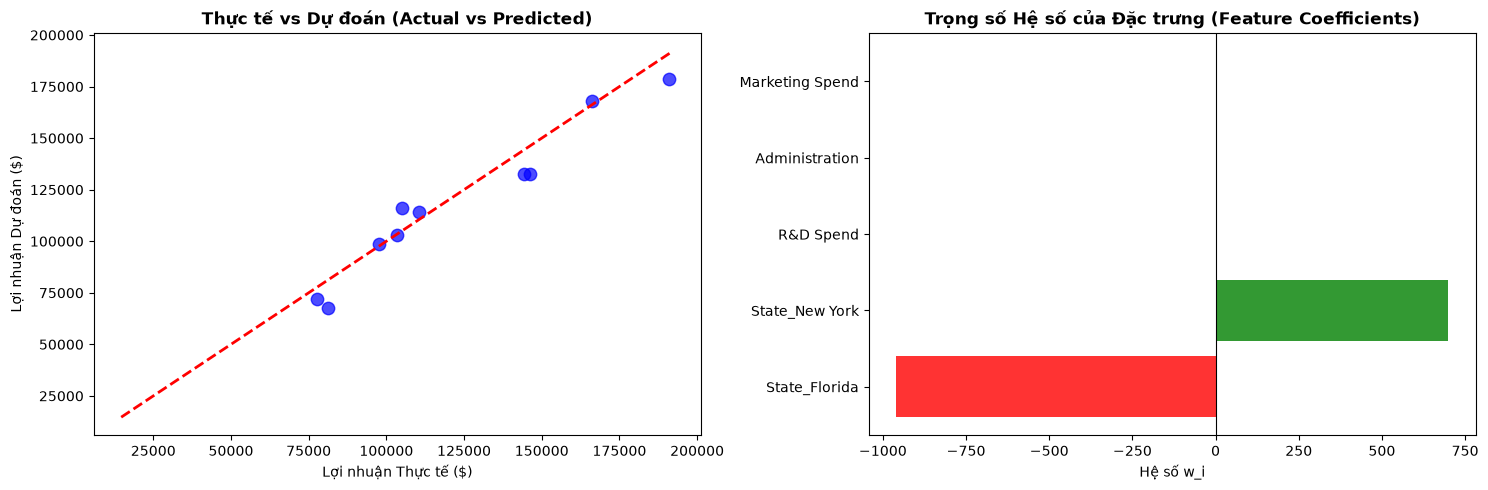

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='blue', s=80, alpha=0.7)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[0].set_title('Thực tế vs Dự đoán (Actual vs Predicted)', fontweight='bold')
axes[0].set_xlabel('Lợi nhuận Thực tế ($)')
axes[0].set_ylabel('Lợi nhuận Dự đoán ($)')

# Đồ thị 2: Trọng số của các đặc trưng
colors = ['green' if c > 0 else 'red' for c in regressor.coef_]
axes[1].barh(feature_names, regressor.coef_, color=colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Trọng số Hệ số của Đặc trưng (Feature Coefficients)', fontweight='bold')
axes[1].set_xlabel('Hệ số w_i')

plt.tight_layout()
plt.show()


📌 **Expected Output:**
- Đồ thị bên trái: Các điểm dự đoán bám rất sát đường chéo lý tưởng $y = x$ ($R^2 \\approx 93.47\\%$).
- Đồ thị bên phải: `R&D Spend` có trọng số dương vượt trội ($w \\approx 0.7735$), là động lực chính thúc đẩy lợi nhuận doanh nghiệp. Các biến `State` và `Administration` có trọng số nhỏ.

---
### 💡 Câu hỏi Thảo luận cho Học viên:
1. **Bẫy Biến Giả (Dummy Variable Trap):** Tại sao khi biến `State` có 3 nhóm (New York, California, Florida) thì ta chỉ đưa 2 cột vào mô hình (`drop='first'`)? Nếu đưa cả 3 cột vào thì hiện tượng gì sẽ xảy ra với ma trận $(\mathbf{X}^T \mathbf{X})$?
2. **Loại Bỏ Ngược (Backward Elimination):** Dựa vào bảng OLS Summary, hai biến giả của `State` có $p\text{-value}$ lần lượt là 0.953 và 0.990 (đều $> 0.05$). Bạn có nên loại bỏ `State` ra khỏi mô hình để đơn giản hóa không? Vì sao?
3. **Ý nghĩa Kinh tế:** Hệ số $w = 0.7735$ của `R&D Spend` có ý nghĩa gì đối với việc ra quyết định đầu tư ngân sách của ban điều hành startup?